# Lab 5 — Wireless Channels: Path Loss, Multipath, Fading and Doppler

**Companion to Chapter 5.** Objectives:

1. Separate the three scales of propagation: path loss, shadowing and small-scale fading.
2. Relate delay spread to coherence bandwidth, and Doppler spread to coherence time.
3. Generate Rayleigh/Rician fading with the right Doppler spectrum and verify its statistics.
4. Measure the cost of fading on BER, the motivation for diversity and coding.
5. Estimate a channel impulse response by correlation, as `gr03_channel_sounder.py` does.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j0
from ipywidgets import interact, FloatSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(5)

## 1. Large-scale: path loss and shadowing
Received power in dB = $P_t - \mathrm{PL}(d) + X_\sigma$, where the log-distance
model uses exponent $n$ (2 in free space, 2.7–3.5 urban, 4+ indoors through walls)
and $X_\sigma$ is log-normal shadowing, typically $\sigma$ = 4–10 dB.

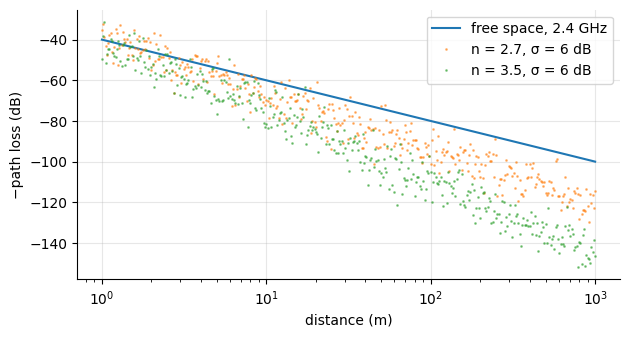

In [3]:
d = np.logspace(0, 3, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogx(d, -cl.fspl_db(d, 2.4e9), label="free space, 2.4 GHz")
for n in [2.7, 3.5]:
    ax.semilogx(d, -cl.log_distance_pl_db(d, 2.4e9, n=n, sigma_db=6, rng=rng), ".", ms=2, alpha=0.5,
                label=f"n = {n}, σ = 6 dB")
ax.set_xlabel("distance (m)"); ax.set_ylabel("−path loss (dB)"); ax.legend(); plt.show()

## 2. Small-scale: the Rayleigh envelope and its Doppler spectrum
With many scatterers and no line of sight, the complex gain is circularly
symmetric Gaussian, so $|h|$ is Rayleigh and $|h|^2$ exponential. Under Clarke's
isotropic-scattering model the autocorrelation is $J_0(2\pi f_D \tau)$ and the
spectrum is the "bathtub" $S(f) \propto 1/\sqrt{1-(f/f_D)^2}$.

Coherence time ≈ 0.423/fD = 4.23 ms


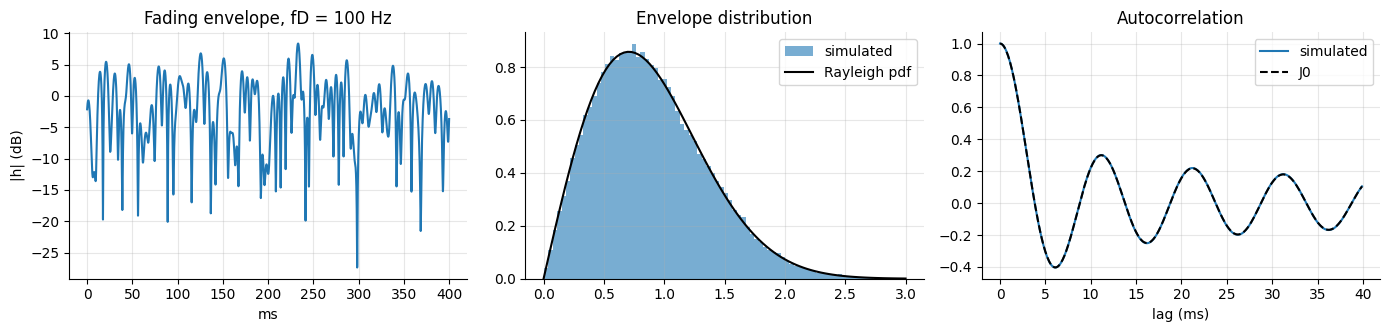

In [5]:
fs = 10e3; fd = 100.0
g = cl.jakes_process(200_000, fd / fs, n_sin=32, rng=rng)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.4))
tt = np.arange(4000) / fs
ax[0].plot(tt * 1e3, 20 * np.log10(np.abs(g[:4000]))); ax[0].set_xlabel("ms"); ax[0].set_ylabel("|h| (dB)")
ax[0].set_title(f"Fading envelope, fD = {fd:.0f} Hz")
r = np.abs(g) / np.sqrt(np.mean(np.abs(g) ** 2))
x = np.linspace(0, 3, 100)
ax[1].hist(r, 80, density=True, alpha=0.6, label="simulated"); ax[1].plot(x, 2 * x * np.exp(-x ** 2), "k", label="Rayleigh pdf")
ax[1].legend(); ax[1].set_title("Envelope distribution")
lags = np.arange(0, 400)
ac = np.array([np.mean(g[:-400] * np.conj(g[l:len(g) - 400 + l])) for l in lags]).real
ax[2].plot(lags / fs * 1e3, ac / ac[0], label="simulated"); ax[2].plot(lags / fs * 1e3, j0(2 * np.pi * fd * lags / fs), "k--", label="J0")
ax[2].set_xlabel("lag (ms)"); ax[2].legend(); ax[2].set_title("Autocorrelation")
plt.tight_layout(); plt.show()
print(f"Coherence time ≈ 0.423/fD = {0.423/fd*1e3:.2f} ms")

## 3. Frequency selectivity: tapped-delay-line models
The LTE extended models (3GPP TS 36.101 Annex B) remain the most widely used
quick-look profiles: EPA (410 ns max delay), EVA (2.51 µs) and ETU (5 µs).
5G NR uses the TDL-A…E and CDL models of TR 38.901, which scale a normalized
profile by a chosen RMS delay spread.

### Interactive: time–frequency channel response
The image shows $|H(f,t)|$ over a 10 MHz band. Coherence bandwidth
$B_c \approx 1/(5\tau_{\mathrm{rms}})$ sets the width of the frequency fades;
Doppler sets how fast they move.

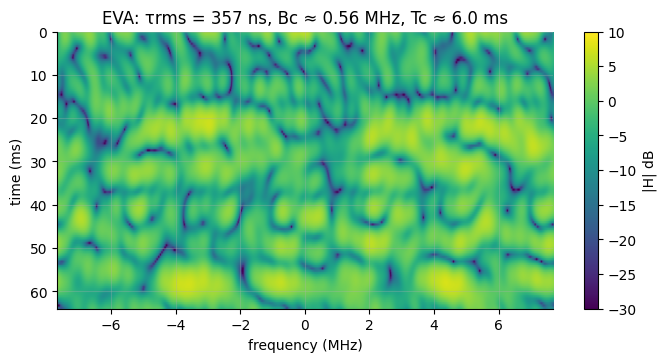

In [7]:
def rms_delay(profile):
    dl, p = cl.TDL_PROFILES[profile]
    p = 10 ** (np.array(p) / 10); p /= p.sum(); dl = np.array(dl) * 1e-9
    return np.sqrt(np.sum(p * dl ** 2) - np.sum(p * dl) ** 2)

def tf_response(profile="EVA", fd_hz=70.0):
    fs = 15.36e6; nfft = 1024; nsym = 120; step = 1024 * 8
    n = nsym * step
    _, taps = cl.tdl_channel(np.ones(n), fs, profile, fd_hz, rng=rng, return_taps=True)
    Ht = np.fft.fftshift(np.fft.fft(taps[::step], nfft, axis=1), axes=1)
    fig, ax = plt.subplots(figsize=(8, 3.6))
    im = ax.imshow(20 * np.log10(np.abs(Ht) + 1e-6), aspect="auto", vmin=-30, vmax=10,
                   extent=[-fs / 2e6, fs / 2e6, nsym * step / fs * 1e3, 0], cmap="viridis")
    tr = rms_delay(profile)
    ax.set_xlabel("frequency (MHz)"); ax.set_ylabel("time (ms)")
    ax.set_title(f"{profile}: τrms = {tr*1e9:.0f} ns, Bc ≈ {1/(5*tr)/1e6:.2f} MHz, "
                 f"Tc ≈ {0.423/max(fd_hz,1e-3)*1e3:.1f} ms")
    plt.colorbar(im, label="|H| dB"); plt.show()

interact(tf_response, profile=Dropdown(options=["EPA", "EVA", "ETU"], value="EVA"),
         fd_hz=FloatSlider(value=70, min=0, max=500, step=5, description="fD Hz"));

## 4. The price of fading
BPSK in flat Rayleigh fading with perfect CSI: $P_b = \frac12\left(1-\sqrt{\frac{\bar\gamma}{1+\bar\gamma}}\right)\approx \frac{1}{4\bar\gamma}$.
The error rate falls only as $1/\mathrm{SNR}$ (diversity order 1) instead of
exponentially. At $10^{-5}$ the gap is over 30 dB. Diversity (Chapter 10) and
coding with interleaving (Chapters 8–9) are how systems buy it back. The Rician
$K$-factor adds a line-of-sight component and moves the curve toward AWGN.

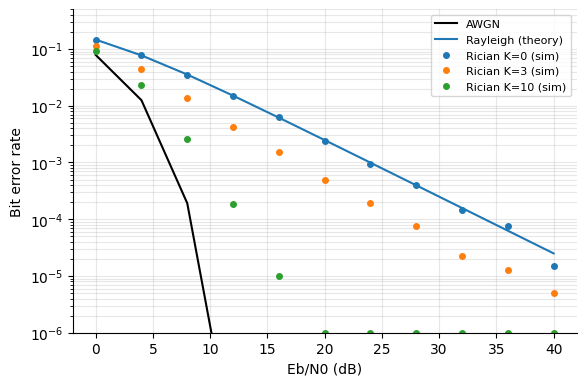

In [9]:
eb = np.arange(0, 41, 4)
bits = cl.random_bits(400_000, rng)
x = 1 - 2 * bits.astype(float)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(eb, cl.ber_bpsk(eb), "k-", label="AWGN")
ax.semilogy(eb, cl.ber_bpsk_rayleigh(eb), "C0-", label="Rayleigh (theory)")
for K in [0, 3, 10]:
    los = np.sqrt(K / (K + 1)); nlos = np.sqrt(1 / (K + 1))
    hch = los + nlos * (rng.standard_normal(len(x)) + 1j * rng.standard_normal(len(x))) / np.sqrt(2)
    ber = []
    for e in eb:
        n0 = 10 ** (-e / 10)
        y = hch * x + np.sqrt(n0 / 2) * (rng.standard_normal(len(x)) + 1j * rng.standard_normal(len(x)))
        ber.append(np.mean((np.real(np.conj(hch) * y) < 0) != bits))
    ax.semilogy(eb, np.maximum(ber, 1e-6), "o", ms=4, label=f"Rician K={K} (sim)")
cl.ber_axes(ax); ax.set_ylim(1e-6, 0.5); ax.legend(fontsize=8); plt.show()

## 5. Channel sounding by correlation
Transmit a sequence with an impulse-like autocorrelation (Zadoff–Chu, m-sequence)
and cross-correlate: the result is the channel impulse response convolved with the
sequence's autocorrelation. This is exactly what `gr03_channel_sounder.py` does
over the air; the same processing reads its recorded files.

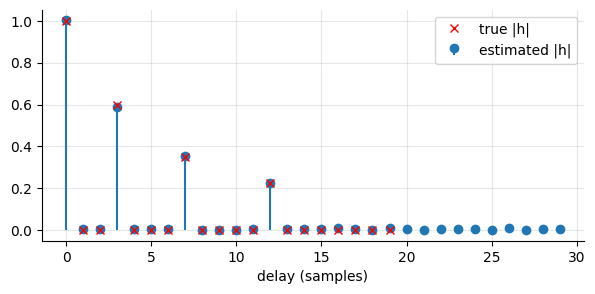

In [11]:
N = 255
zc = cl.zadoff_chu(1, N)
tx = np.tile(zc, 8)
hch = np.zeros(20, complex); hch[[0, 3, 7, 12]] = [1, 0.6j, -0.35, 0.2 + 0.1j]
rx = cl.awgn(np.convolve(tx, hch)[:len(tx)], 15, rng)
# periodic correlation over one period after the first (transient) one
seg = rx[N:N * 7].reshape(6, N).mean(axis=0)
cir = np.fft.ifft(np.fft.fft(seg) * np.conj(np.fft.fft(zc))) / N
fig, ax = plt.subplots(figsize=(7, 3))
ax.stem(np.arange(30), np.abs(cir[:30]), basefmt=" ", label="estimated |h|")
ax.plot(np.arange(20), np.abs(hch), "rx", label="true |h|"); ax.legend(); ax.set_xlabel("delay (samples)")
plt.show()

## Exercises
1. **(Warm-up)** Compute τrms for EPA, EVA and ETU by hand and confirm the slider titles.
2. **(Core)** For an NR carrier at 3.5 GHz with 30 kHz subcarrier spacing, what UE speed
   makes the Doppler 5% of the subcarrier spacing? Why is that a useful threshold (Ch. 7)?
3. **(Core)** Estimate the Rician K-factor from simulated envelope samples using the
   moment method $K = \sqrt{1-\gamma}/(1-\sqrt{1-\gamma})$, $\gamma = \mathrm{Var}(|h|^2)/E[|h|^2]^2$.
4. **(Stretch)** Record a sounder capture with gr03 in a hallway while walking, then
   estimate the power-delay profile, τrms and the Doppler spectrum of each tap.